In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_data=pd.read_csv('/content/titanic_dataset.csv')

In [3]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_data.set_index('PassengerId', inplace=True)
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
titanic_data.shape

(891, 11)

In [6]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [7]:
titanic_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
titanic_data.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


missing values

age is  numerical column


embarked,cabin is object columns

In [9]:
titanic_data.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


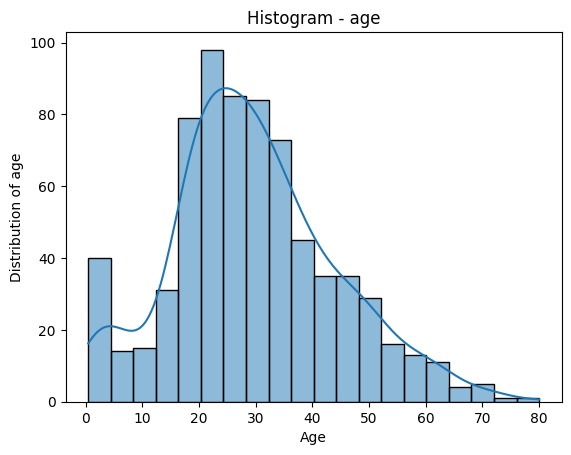

In [10]:
sns.histplot(titanic_data['Age'],kde = True)
plt.xlabel('Age')
plt.ylabel('Distribution of age')
plt.title('Histogram - age')
plt.show()

In [11]:
titanic_data['Age'].median()

28.0

In [12]:
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].median())

In [13]:
titanic_data.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [14]:
titanic_data['Embarked'].nunique()

3

In [15]:
titanic_data['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [16]:
titanic_data['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [17]:
titanic_data['Embarked'].mode()[0]

'S'

In [18]:
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0])

In [19]:
titanic_data.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


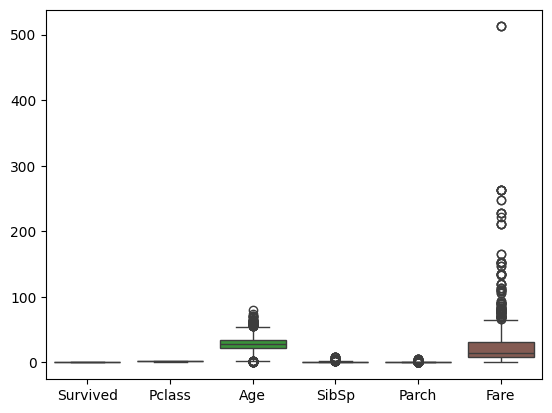

In [20]:
sns.boxplot(titanic_data)
plt.show()

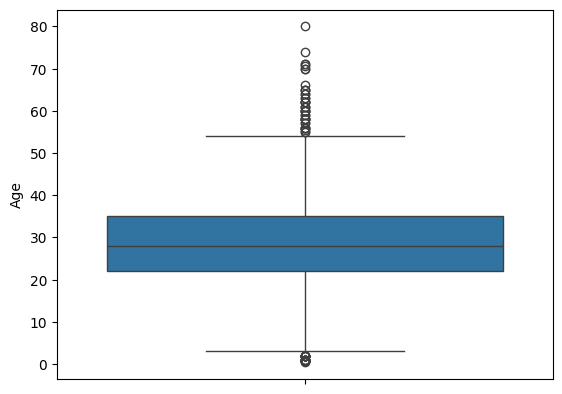

In [21]:
sns.boxplot(titanic_data['Age'])
plt.show()

In [22]:
q1 = titanic_data['Age'].quantile(0.25)
q3 = titanic_data['Age'].quantile(0.75)

print(f'Q1 = {q1}\nQ3 = {q3}')

iqr = q3 - q1

up_lim_Age = q3 + (1.5 * iqr)
low_lim_Age = q1 - (1.5 * iqr)

print(f'IQR = {iqr}\nUp_lim = {up_lim_Age}\nLow_lim = {low_lim_Age}')

Q1 = 22.0
Q3 = 35.0
IQR = 13.0
Up_lim = 54.5
Low_lim = 2.5


In [23]:
outliers = titanic_data[(titanic_data['Age'] > up_lim_Age) | (titanic_data['Age'] < low_lim_Age)]
outliers

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
8,0,3,male,2.00,3,1,21.0750,S
12,1,1,female,58.00,0,0,26.5500,S
16,1,2,female,55.00,0,0,16.0000,S
17,0,3,male,2.00,4,1,29.1250,Q
34,0,2,male,66.00,0,0,10.5000,S
...,...,...,...,...,...,...,...,...
828,1,2,male,1.00,0,2,37.0042,C
830,1,1,female,62.00,0,0,80.0000,S
832,1,2,male,0.83,1,1,18.7500,S


In [24]:
titanic_data.loc[titanic_data['Age'] > up_lim_Age,'Age'] = up_lim_Age

titanic_data.loc[titanic_data['Age'] < low_lim_Age,'Age'] = low_lim_Age

In [25]:
titanic_data['Age'].unique()

array([22. , 38. , 26. , 35. , 28. , 54. ,  2.5, 27. , 14. ,  4. , 54.5,
       20. , 39. , 31. , 34. , 15. ,  8. , 19. , 40. , 42. , 21. , 18. ,
        3. ,  7. , 49. , 29. , 28.5,  5. , 11. , 45. , 17. , 32. , 16. ,
       25. , 30. , 33. , 23. , 24. , 46. , 37. , 47. , 14.5, 32.5, 12. ,
        9. , 36.5, 51. , 40.5, 44. , 50. , 36. , 45.5, 20.5, 41. , 52. ,
       23.5, 43. , 10. , 13. , 48. , 53. , 24.5,  6. , 30.5, 34.5])

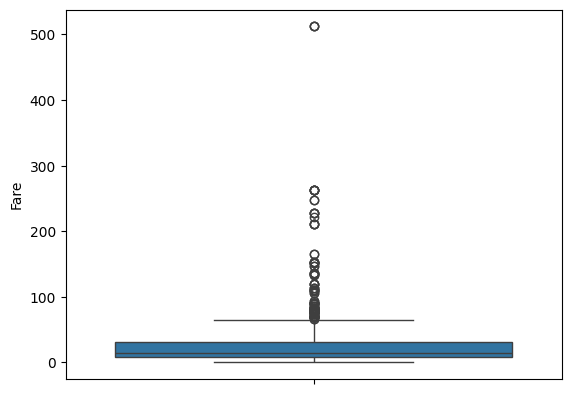

In [26]:
sns.boxplot(titanic_data['Fare'])
plt.show()

In [27]:
q1 = titanic_data['Fare'].quantile(0.25)
q3 = titanic_data['Fare'].quantile(0.75)

print(f'Q1 = {q1}\nQ3 = {q3}')

iqr = q3 - q1

up_lim_Fare = q3 + (1.5 * iqr)
low_lim_Fare = q1 - (1.5 * iqr)

print(f'IQR = {iqr}\nUp_lim = {up_lim_Fare}\nLow_lim = {low_lim_Fare}')

Q1 = 7.9104
Q3 = 31.0
IQR = 23.0896
Up_lim = 65.6344
Low_lim = -26.724


In [28]:
outliers_fare = titanic_data[(titanic_data['Fare'] > up_lim_Fare) | (titanic_data['Fare'] < low_lim_Fare)]
outliers_fare

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
2,1,1,female,38.0,1,0,71.2833,C
28,0,1,male,19.0,3,2,263.0000,S
32,1,1,female,28.0,1,0,146.5208,C
35,0,1,male,28.0,1,0,82.1708,C
53,1,1,female,49.0,1,0,76.7292,C
...,...,...,...,...,...,...,...,...
847,0,3,male,28.0,8,2,69.5500,S
850,1,1,female,28.0,1,0,89.1042,C
857,1,1,female,45.0,1,1,164.8667,S


In [29]:
titanic_data.loc[titanic_data['Fare'] > up_lim_Fare,'Fare'] = up_lim_Fare

titanic_data.loc[titanic_data['Fare'] < low_lim_Fare,'Fare'] = low_lim_Fare

In [30]:
titanic_data['Fare'].unique()

array([ 7.25  , 65.6344,  7.925 , 53.1   ,  8.05  ,  8.4583, 51.8625,
       21.075 , 11.1333, 30.0708, 16.7   , 26.55  , 31.275 ,  7.8542,
       16.    , 29.125 , 13.    , 18.    ,  7.225 , 26.    ,  8.0292,
       35.5   , 31.3875,  7.8792,  7.8958, 27.7208,  7.75  , 10.5   ,
       52.    ,  7.2292, 11.2417,  9.475 , 21.    , 41.5792, 15.5   ,
       21.6792, 17.8   , 39.6875,  7.8   , 61.9792, 27.75  , 46.9   ,
       27.9   , 15.2458,  8.1583,  8.6625, 14.4542, 56.4958,  7.65  ,
       29.    , 12.475 ,  9.    ,  9.5   ,  7.7875, 47.1   , 15.85  ,
       34.375 , 61.175 , 20.575 , 34.6542, 63.3583, 23.    ,  8.6542,
        7.775 , 24.15  ,  9.825 , 14.4583,  7.1417, 22.3583,  6.975 ,
        7.05  , 14.5   , 15.0458, 26.2833,  9.2167,  6.75  , 11.5   ,
       36.75  ,  7.7958, 12.525 ,  7.3125, 61.3792,  7.7333, 16.1   ,
       15.75  , 20.525 , 55.    , 25.925 , 33.5   , 30.6958, 25.4667,
       28.7125,  0.    , 15.05  , 39.    , 22.025 , 50.    ,  8.4042,
        6.4958, 10.4

In [31]:
titanic_data['Sex'].unique()

array(['male', 'female'], dtype=object)

In [32]:
titanic_data=pd.get_dummies(titanic_data,dtype='int',drop_first=True)
titanic_data

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,
1,0,3,22.0,1,0,7.2500,1,0,1
2,1,1,38.0,1,0,65.6344,0,0,0
3,1,3,26.0,0,0,7.9250,0,0,1
4,1,1,35.0,1,0,53.1000,0,0,1
5,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
887,0,2,27.0,0,0,13.0000,1,0,1
888,1,1,19.0,0,0,30.0000,0,0,1
889,0,3,28.0,1,2,23.4500,0,0,1


In [33]:
x=titanic_data.drop('Survived', axis= 1)
y=titanic_data['Survived']

In [34]:
x.head(3)

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
1,3,22.0,1,0,7.2500,1,0,1
2,1,38.0,1,0,65.6344,0,0,0
3,3,26.0,0,0,7.9250,0,0,1


In [35]:
y.head(3)

,Survived
PassengerId,
1,0
2,1
3,1


In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train[['Age', 'Fare']] = scaler.fit_transform(x_train[['Age', 'Fare']])
x_test[['Age', 'Fare']] = scaler.transform(x_test[['Age', 'Fare']])

In [38]:
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
693,3,-0.095167,0,0,1.587890,1,0,1
482,2,-0.095167,0,0,-1.168968,1,0,1
528,1,-0.095167,0,0,2.033832,1,0,1
856,3,-0.921491,0,1,-0.712711,0,0,1
802,2,0.152731,1,1,0.111968,0,0,1


In [39]:
x_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
566,3,-0.425696,2,0,0.009493,1,0,1
161,3,1.226953,0,1,-0.383327,1,0,1
554,3,-0.590961,0,0,-0.816406,1,0,0
861,3,0.979055,2,0,-0.480517,1,0,1
242,3,-0.095167,1,0,-0.412606,0,1,0


In [40]:
y_test.head(3)

,Survived
PassengerId,
566,0
161,0
554,1


In [41]:
y_train.head(3)

,Survived
PassengerId,
693,1
482,0
528,0


#logistics regression

In [42]:
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,f1_score,recall_score

In [43]:
from sklearn.linear_model import LogisticRegression
lr_model =LogisticRegression(max_iter=1000)
lr_model.fit(x_train,y_train)
y_pred_lr_model = lr_model.predict(x_test)
print(confusion_matrix(y_test,y_pred_lr_model))
print('Accuracy is: ',accuracy_score(y_test,y_pred_lr_model))
print('Precision is: ',precision_score(y_test,y_pred_lr_model))
print('Recall is: ',recall_score(y_test,y_pred_lr_model))
print('F1 score is: ',f1_score(y_test,y_pred_lr_model))

[[96 14]
 [23 46]]
Accuracy is:  0.7932960893854749
Precision is:  0.7666666666666667
Recall is:  0.6666666666666666
F1 score is:  0.7131782945736435


#KNN

In [44]:
from sklearn.neighbors import KNeighborsClassifier

acc_score =[]
for i in range(3,10):
  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(x_train,y_train)
  y_pred_knn = knn.predict(x_test)
  acc = accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

In [45]:
acc_score

[0.7877094972067039,
 0.7877094972067039,
 0.770949720670391,
 0.776536312849162,
 0.776536312849162,
 0.776536312849162,
 0.7653631284916201]

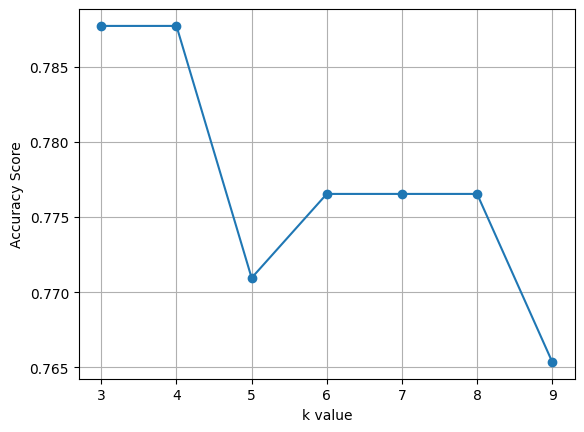

In [46]:
plt.plot(np.arange(3,10),acc_score,'o-')
plt.xlabel('k value')
plt.ylabel('Accuracy Score')
plt.grid()

In [47]:
knn= KNeighborsClassifier(n_neighbors=4)
knn.fit(x_train,y_train)
y_pred_knn = knn.predict(x_test)
print(confusion_matrix(y_test,y_pred_knn))
print('Accuracy is : ',accuracy_score(y_test,y_pred_knn))
print('Precision is : ',precision_score(y_test,y_pred_knn))
print('Recall is : ',recall_score(y_test,y_pred_knn))
print('F1 score is : ',f1_score(y_test,y_pred_knn))

[[101   9]
 [ 29  40]]
Accuracy is :  0.7877094972067039
Precision is :  0.8163265306122449
Recall is :  0.5797101449275363
F1 score is :  0.6779661016949152


In [48]:
from sklearn.svm import SVC

#linear kernal

In [50]:
#linear kernal
svm_linear =  SVC(kernel = 'linear')
svm_linear.fit(x_train,y_train)
y_pred_svm_linear = svm_linear.predict(x_test)
print(confusion_matrix(y_test,y_pred_svm_linear))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_linear))
print('Precision is : ',precision_score(y_test,y_pred_svm_linear))
print('Recall is : ',recall_score(y_test,y_pred_svm_linear))
print('F1 score is : ',f1_score(y_test,y_pred_svm_linear))

[[94 16]
 [24 45]]
Accuracy is :  0.776536312849162
Precision is :  0.7377049180327869
Recall is :  0.6521739130434783
F1 score is :  0.6923076923076923


#polynomial kernal

In [52]:
#polynomial kernal
svm_poly =  SVC(kernel = 'poly')
svm_poly.fit(x_train,y_train)
y_pred_svm_poly = svm_poly.predict(x_test)
print(confusion_matrix(y_test,y_pred_svm_poly))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_poly))
print('Precision is : ',precision_score(y_test,y_pred_svm_poly))
print('Recall is : ',recall_score(y_test,y_pred_svm_poly))
print('F1 score is : ',f1_score(y_test,y_pred_svm_poly))

[[95 15]
 [21 48]]
Accuracy is :  0.7988826815642458
Precision is :  0.7619047619047619
Recall is :  0.6956521739130435
F1 score is :  0.7272727272727273


rbf

In [53]:

svm_rbf =  SVC(kernel = 'rbf')
svm_rbf.fit(x_train,y_train)
y_pred_svm_rbf = svm_rbf.predict(x_test)
print(confusion_matrix(y_test,y_pred_svm_rbf))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_rbf))
print('Precision is : ',precision_score(y_test,y_pred_svm_rbf))
print('Recall is : ',recall_score(y_test,y_pred_svm_rbf))
print('F1 score is : ',f1_score(y_test,y_pred_svm_rbf))

[[100  10]
 [ 21  48]]
Accuracy is :  0.8268156424581006
Precision is :  0.8275862068965517
Recall is :  0.6956521739130435
F1 score is :  0.7559055118110236


# Decision tree

In [54]:
# Decision tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state= 42)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(confusion_matrix(y_test,y_pred_dt))
print('Accuracy is : ',accuracy_score(y_test,y_pred_dt))
print('Precision is : ',precision_score(y_test,y_pred_dt))
print('Recall is : ',recall_score(y_test,y_pred_dt))
print('F1 score is : ',f1_score(y_test,y_pred_dt))

[[95 15]
 [22 47]]
Accuracy is :  0.7932960893854749
Precision is :  0.7580645161290323
Recall is :  0.6811594202898551
F1 score is :  0.7175572519083969


# Random forest

In [55]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
rf =  RandomForestClassifier(criterion='entropy',random_state= 42)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print(confusion_matrix(y_test,y_pred_rf))
print('Accuracy is : ',accuracy_score(y_test,y_pred_rf))
print('Precision is : ',precision_score(y_test,y_pred_rf))
print('Recall is : ',recall_score(y_test,y_pred_rf))
print('F1 score is : ',f1_score(y_test,y_pred_rf))

[[94 16]
 [23 46]]
Accuracy is :  0.7821229050279329
Precision is :  0.7419354838709677
Recall is :  0.6666666666666666
F1 score is :  0.7022900763358778
